In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import skew, kurtosis

In [23]:
df = pd.read_csv('household_dataset.csv')
df

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
0,H001,65,1212,Primary,5,Yes,Urban
1,H002,33,1139,Primary,7,Yes,Urban
2,H003,30,2091,Secondary,1,Yes,Rural
3,H004,39,3979,Graduate,1,Yes,Rural
4,H005,46,2576,Secondary,4,No,Urban
...,...,...,...,...,...,...,...
155,H156,46,4671,Post-Grad,6,No,Urban
156,H157,64,860,Secondary,5,Yes,Urban
157,H158,52,1106,Primary,8,Yes,Rural
158,H159,26,676,Graduate,1,No,Rural


In [24]:
df.dtypes

Household_ID             object
Age_of_Household_Head     int64
Household_Income          int64
Education_Level          object
Family_Size               int64
Owns_House               object
Urban_Rural              object
dtype: object

In [25]:
df.isnull().sum()

Household_ID             0
Age_of_Household_Head    0
Household_Income         0
Education_Level          0
Family_Size              0
Owns_House               0
Urban_Rural              0
dtype: int64

In [26]:
df.dropna

<bound method DataFrame.dropna of     Household_ID  Age_of_Household_Head  Household_Income Education_Level  \
0           H001                     65              1212         Primary   
1           H002                     33              1139         Primary   
2           H003                     30              2091       Secondary   
3           H004                     39              3979        Graduate   
4           H005                     46              2576       Secondary   
..           ...                    ...               ...             ...   
155         H156                     46              4671       Post-Grad   
156         H157                     64               860       Secondary   
157         H158                     52              1106         Primary   
158         H159                     26               676        Graduate   
159         H160                     48              3828       Secondary   

     Family_Size Owns_House Urban_Rural  

In [27]:
print("categorical columns:")
print(df.select_dtypes(include=['object']).columns)

categorical columns:
Index(['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural'], dtype='object')


In [28]:
print("Numerical Columns:")
print(df.select_dtypes(include=['int64','float64']).columns)

Numerical Columns:
Index(['Age_of_Household_Head', 'Household_Income', 'Family_Size'], dtype='object')


In [29]:
mean_income = df["Household_Income"].mean()
median_income = df["Household_Income"].median()
mode_income =  df["Household_Income"].mode()[0]

In [30]:
mean_age = df["Age_of_Household_Head"].mean()
median_age = df["Age_of_Household_Head"].median()
mode_age = df["Age_of_Household_Head"].mode()

In [31]:
print("Income Mean:", mean_income)
print("Income Median:", median_income)
print("Income mode:", mode_income)

Income Mean: 2864.23125
Income Median: 2934.5
Income mode: 3612


In [32]:
print("Age Mean:", mean_age)
print("Age median:", median_age)
print("Age mode:", mode_age)

Age Mean: 50.90625
Age median: 52.5
Age mode: 0    46
Name: Age_of_Household_Head, dtype: int64


In [33]:
# Interpretation
if mean_income > median_income:
    print("\nIncome distribution is Right-Skewed (positively skewed).")
elif mean_income < median_income:
    print("\nIncome distribution is Left-Skewed (negatively skewed).")
else:
    print("\nIncome distribution is Symmetrical.")


Income distribution is Left-Skewed (negatively skewed).


In [34]:
range_income = df["Household_Income"].max() - df["Household_Income"].min()
variance_icome = df["Household_Income"].var()
std_income = df["Household_Income"].std()

In [35]:
print("income range:", range_income)
print("Income Variance:", variance_icome)
print("income standard deviation:", std_income)

income range: 4659
Income Variance: 1860099.2732311322
income standard deviation: 1363.8545645453303


In [36]:
Q1 = df["Household_Income"].quantile(0.25)
Q3 = df["Household_Income"].quantile(0.75)
IQR = Q3 - Q1

In [37]:
print("q1:",Q1)
print("q3:",Q3)
print("IQR:",IQR)

q1: 1839.75
q3: 4064.75
IQR: 2225.0


NameError: name 'norm' is not defined

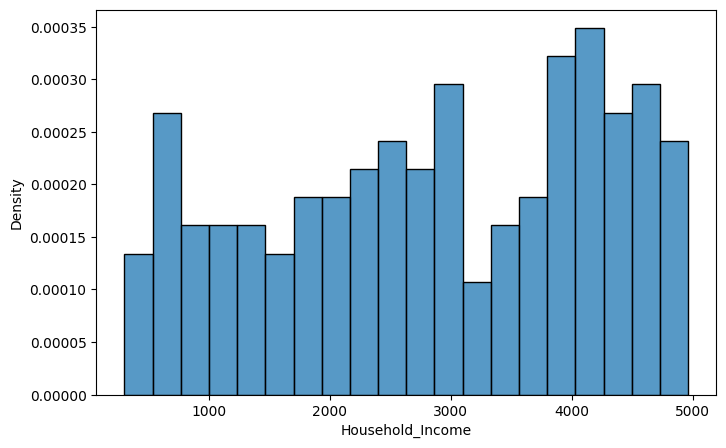

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['Household_Income'], kde=False, stat="density", bins=20)

mu, std = norm.fit(df['Household_Income'])

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title("Household Income Distribution with Gaussian Fit")
plt.xlabel("Household Income")
plt.ylabel("Density")
plt.show()

print("\nGaussian Fit Parameters:")
print("Mean (mu):", mu)
print("Standard Deviation (sigma):", std)

income_skewness = skew(df['Household_Income'])
income_kurtosis = kurtosis(df['Household_Income'])

print("\n--- Shape of Distribution ---")
print("Skewness:", income_skewness)
print("Kurtosis:", income_kurtosis)

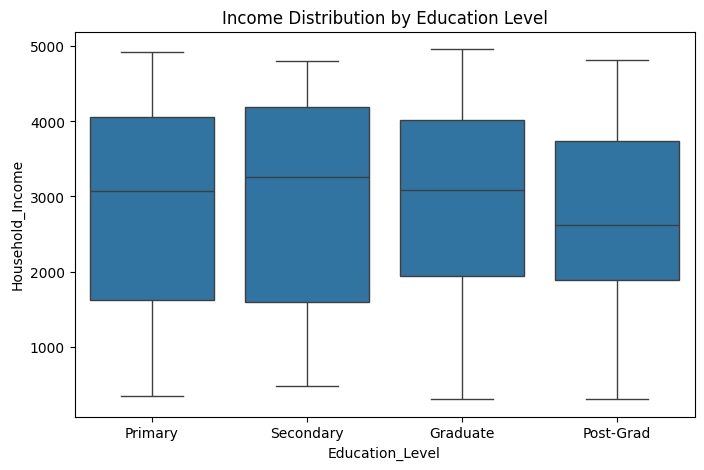

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Education_Level", y="Household_Income", data=df)
plt.title("Income Distribution by Education Level")
plt.show()

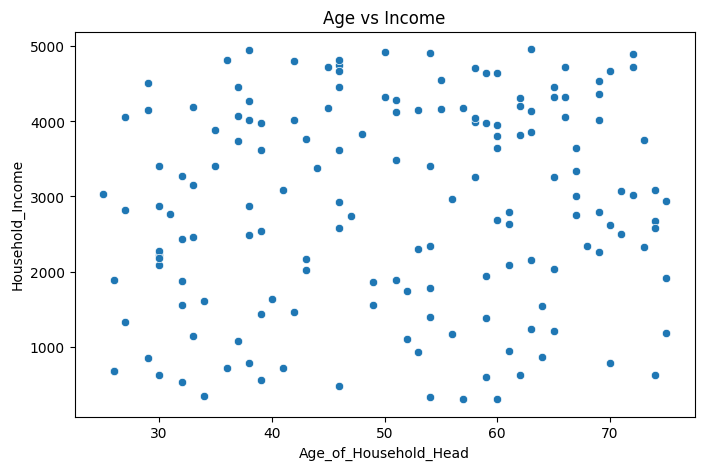

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age_of_Household_Head", y="Household_Income", data=df)
plt.title("Age vs Income")
plt.show()

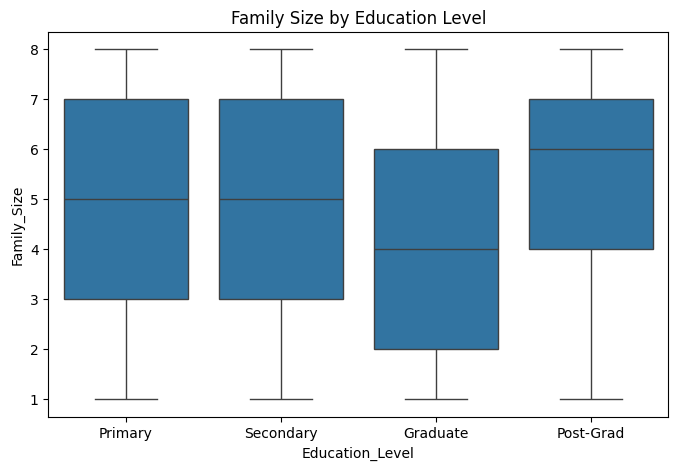

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(x="Education_Level", y="Family_Size", data=df)
plt.title("Family Size by Education Level")
plt.show()

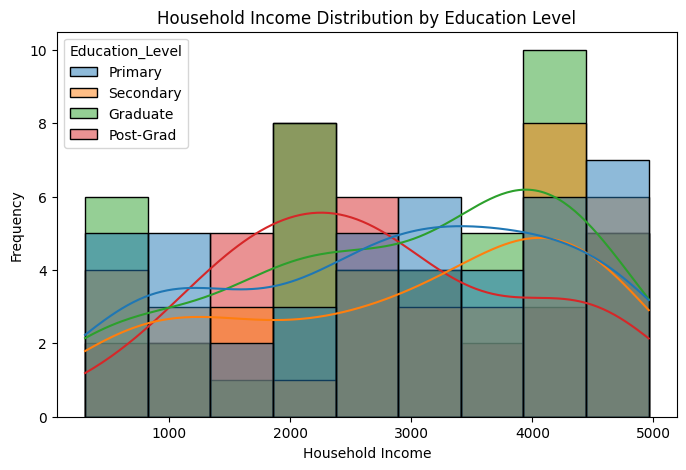

In [ ]:

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Household_Income", hue="Education_Level", kde=True)
plt.title("Household Income Distribution by Education Level")
plt.xlabel("Household Income")
plt.ylabel("Frequency")
plt.show()

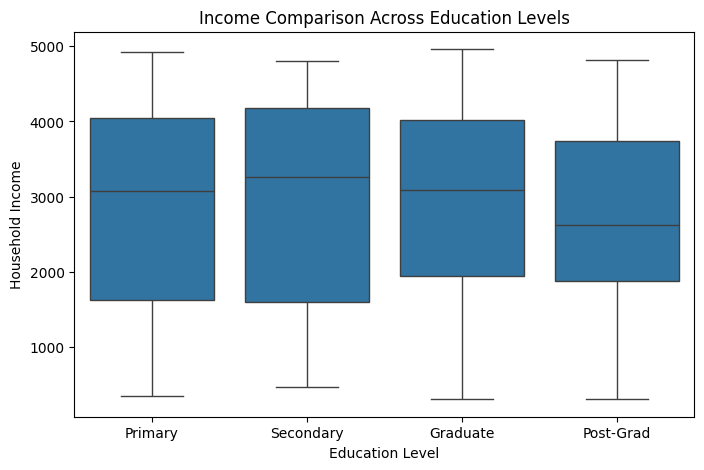

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Education_Level", y="Household_Income", data=df)
plt.title("Income Comparison Across Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Household Income")
plt.show()

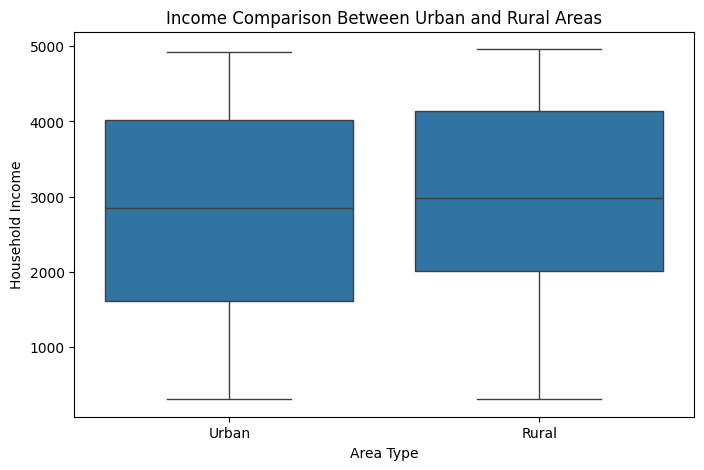

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Urban_Rural", y="Household_Income", data=df)
plt.title("Income Comparison Between Urban and Rural Areas")
plt.xlabel("Area Type")
plt.ylabel("Household Income")
plt.show()